In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def build_generator():
  model = tf.keras.Sequential()
  model.add(layers.Dense(128, input_shape=(100,), use_bias=False))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU(alpha=0.01))

  model.add(layers.Dense(784, activation='tanh'))
  model.add(layers.Reshape((28, 28, 1)))
  return model

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28, 1)))

    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [ ]:
def build_gan(generator, discriminator):
    # Removed: discriminator.trainable = False
    model = tf.keras.Sequential([generator, discriminator])
    return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()
gan = build_gan(generator, discriminator)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
discriminator.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(0.0002, 0.5))
gan.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(0.0002, 0.5))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch 0, D Loss: 1.1175447702407837, G Loss: 0.49002447724342346
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


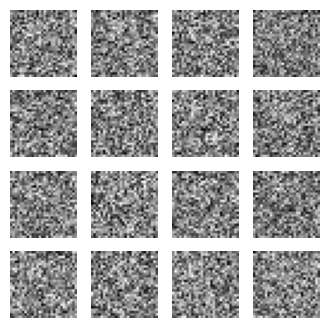

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [ ]:
epochs = 10
batch_size = 64
for epoch in range(epochs):
    idx = np.random.randint(0, train_images.shape[0], batch_size)
    real_images = train_images[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    generated_images = generator.predict(noise)

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    # Train discriminator
    discriminator.trainable = True # Ensure discriminator is trainable for its own training
    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train generator (via GAN)
    discriminator.trainable = False # Freeze discriminator for generator training
    g_loss = gan.train_on_batch(noise, fake_labels)

    # Re-enable discriminator training for the next iteration
    discriminator.trainable = True

    if epoch % 100 == 0:
        print("Epoch {}, D Loss: {}, G Loss: {}".format(epoch, d_loss, g_loss))

    # Save generated images for visualization
    if epoch % 1000 == 0:
        generated_images = generator.predict(np.random.normal(0, 1, (16, 100)))
        generated_images = 0.5 * generated_images + 0.5 # Rescale images
        plt.figure(figsize=(4, 4))
        for i in range(generated_images.shape[0]):
            plt.subplot(4, 4, i + 1)
            plt.imshow(generated_images[i, :, :, 0], cmap='gray')
            plt.axis('off')
        plt.show()